# HOMEWORK


## Bài 1: Titanic Dataset

### Import & cấu hình

In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, RobustScaler, StandardScaler

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")
np.random.seed(42)          # cố định ngẫu nhiên -> kết quả tái lập được
print("Sẵn sàng.")

Sẵn sàng.


### Tải dữ liệu

In [39]:
try:
    df = sns.load_dataset("titanic")
    print("Đã tải từ seaborn.")
except Exception:
    url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
    df = pd.read_csv(url)
    df.columns = [c.lower() for c in df.columns]
    print("Đã tải từ URL.")
df.head()

Đã tải từ seaborn.


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


### `shape`, `info`, `describe`

In [40]:
print("Biến mục tiêu: 'Survived' |", df.shape[0], "mẫu,", df.shape[1], "cột")
df.info()

Biến mục tiêu: 'Survived' | 891 mẫu, 15 cột
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


In [41]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
survived,891.0,NaN,NaN,NaN,0.383838,0.486592,0.0,0.0,0.0,1.0,1.0
pclass,891.0,NaN,NaN,NaN,2.308642,0.836071,1.0,2.0,3.0,3.0,3.0
sex,891,2,male,577,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,714.0,NaN,NaN,NaN,29.699118,14.526497,0.42,20.125,28.0,38.0,80.0
sibsp,891.0,NaN,NaN,NaN,0.523008,1.102743,0.0,0.0,0.0,1.0,8.0
parch,891.0,NaN,NaN,NaN,0.381594,0.806057,0.0,0.0,0.0,0.0,6.0
fare,891.0,NaN,NaN,NaN,32.204208,49.693429,0.0,7.9104,14.4542,31.0,512.3292
embarked,889,3,S,644,NaN,NaN,NaN,NaN,NaN,NaN,NaN
class,891,3,Third,491,NaN,NaN,NaN,NaN,NaN,NaN,NaN
who,891,3,man,537,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Missing Value + đề xuất xử lý

Cột `deck` thiếu rất nhiều (~77%) — sẽ **loại bỏ**. `Age` thiếu vừa phải → điền **median**. `Embarked` thiếu rất ít → điền **mode**.

In [42]:
miss = (df.isnull().mean() * 100).round(1).sort_values(ascending=False)
miss = miss[miss > 0]
print(miss)

deck           77.2
age            19.9
embarked        0.2
embark_town     0.2
dtype: float64


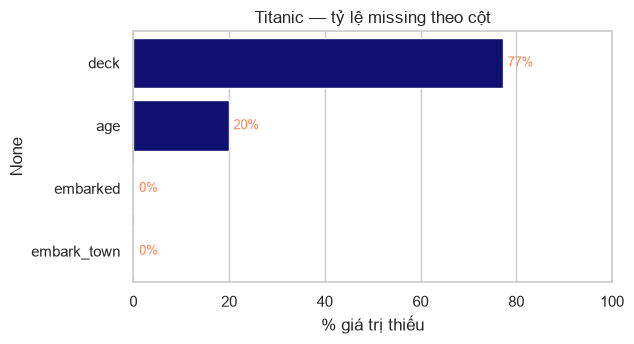

In [43]:

# Hình cho slide: % missing theo cột
plt.figure(figsize=(6.5, 3.6))
sns.barplot(x=miss.values, y=miss.index, color="navy")
for i, v in enumerate(miss.values):
    plt.text(v + 1, i, f"{v:.0f}%", va="center", fontsize=9, color="coral")
plt.xlabel("% giá trị thiếu"); plt.title("Titanic — tỷ lệ missing theo cột")
plt.xlim(0, 100); plt.tight_layout()
plt.show()

In [44]:
# Loại cột thiếu quá nhiều (deck/Cabin) khỏi tập đặc trưng
for c in ["deck", "Cabin"]:
    if c in df.columns:
        df = df.drop(columns=c)
print("Sau khi bỏ cột thiếu nặng:", list(df.columns))

Sau khi bỏ cột thiếu nặng: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'embark_town', 'alive', 'alone']


### Outlier + **quyết định xử lý**

Không chỉ phát hiện, phải **quyết định** làm gì với chúng.

In [45]:
# TODO 4: đếm outlier theo IQR và Z-score cho 'age' và 'fare'
def dem_outlier_iqr(s):
    Q1 = np.quantile(s,0.25)
    Q3 = np.quantile(s,0.75)
    IQR = Q3 - Q1
    return ((s < Q1-1.5*IQR) | (s > Q3+1.5*IQR)).sum()   # trả về số lượng outlier theo IQR

def dem_outlier_zscore(s, nguong=3.0):
    z = np.abs(stats.zscore(s.dropna()))
    return (z > nguong).sum()    # trả về số lượng outlier theo Z-score

for col in ["age", "fare"]:
    print(dem_outlier_iqr(df[col]))
    print(dem_outlier_zscore(df[col]))

0
2
116
20


**Quyết định:** `Fare` có nhiều outlier theo IQR, nhưng đó là **vé hạng nhất có thật** (giá trị hợp lệ), không phải lỗi nhập liệu. → **Giữ lại** và dùng **RobustScaler** (bền vững với outlier) thay vì xóa. `Age` outlier không đáng kể.

### Trực quan hóa 

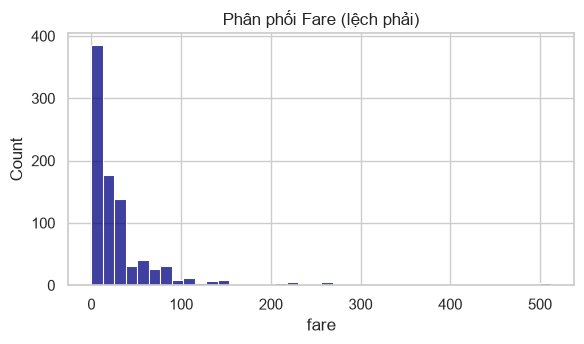

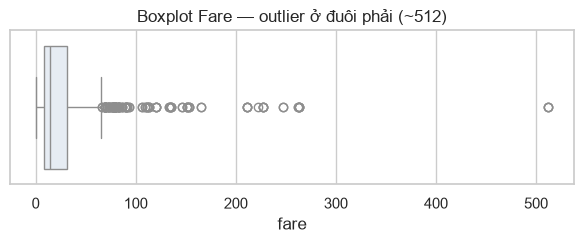

In [46]:
# (a) Histogram Fare — lệch phải rõ rệt
plt.figure(figsize=(6, 3.6))
sns.histplot(df["fare"], bins=40, color="NAVY")
plt.title("Phân phối Fare (lệch phải)"); plt.tight_layout()
plt.show()

# (b) Boxplot Fare — chỉ ra outlier ~512
plt.figure(figsize=(6, 2.6))
sns.boxplot(x=df["fare"], color="#E4ECF5")
plt.title("Boxplot Fare — outlier ở đuôi phải (~512)"); plt.tight_layout()
plt.show()

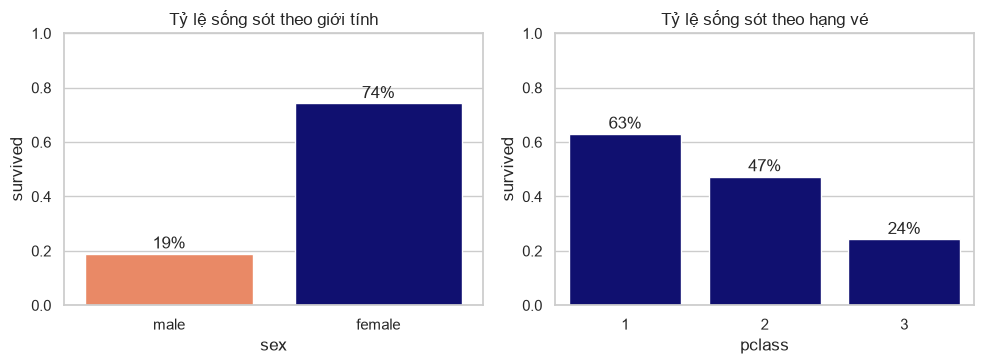

Sống sót:  nữ = 74%  vs  nam = 19%


In [47]:
# (c) Bivariate: tỷ lệ sống sót theo Sex và Pclass
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
sns.barplot(data=df, x="sex", y="survived", hue="sex", legend=False, ax=axes[0], errorbar=None, palette=["CORAL", "NAVY"])
axes[0].set_title("Tỷ lệ sống sót theo giới tính"); axes[0].set_ylim(0, 1)
for p in axes[0].patches:
    axes[0].annotate(f"{p.get_height():.0%}", (p.get_x()+p.get_width()/2, p.get_height()+0.02), ha="center")
sns.barplot(data=df, x="pclass", y="survived", ax=axes[1], errorbar=None, color="NAVY")
axes[1].set_title("Tỷ lệ sống sót theo hạng vé"); axes[1].set_ylim(0, 1)
for p in axes[1].patches:
    axes[1].annotate(f"{p.get_height():.0%}", (p.get_x()+p.get_width()/2, p.get_height()+0.02), ha="center")
plt.tight_layout()
plt.show()

print("Sống sót:  nữ = {:.0%}  vs  nam = {:.0%}".format(
    df.loc[df.sex=="female","survived"].mean(), df.loc[df.sex=="male","survived"].mean()))

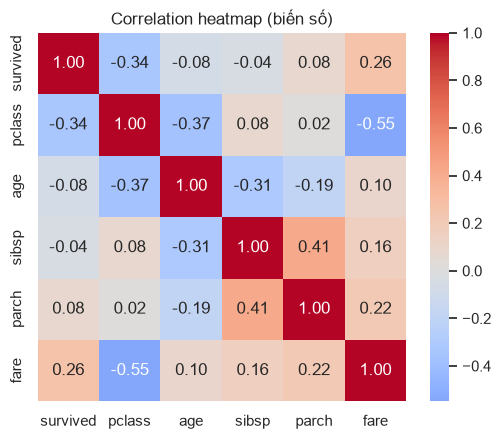

In [48]:
# (d) Correlation heatmap (chỉ biến số, sau khi đã bỏ cột leaky)
num = df.select_dtypes("number")
plt.figure(figsize=(5.5, 4.5))
sns.heatmap(num.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Correlation heatmap (biến số)"); plt.tight_layout()
plt.show()

### Chia tập TRƯỚC (chống data leakage)


In [49]:
X = df.drop(columns="survived")
y = df["survived"]

# 70 / 15 / 15, stratify để giữ tỷ lệ hai lớp
X_train_titanic, X_test_titanic, y_train_titanic, y_test_titanic = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
# X_train, X_val, y_train, y_val = train_test_split(X_tmp, y_tmp, test_size=0.2/0.8, random_state=42, stratify=y_tmp)
print("Train:", X_train_titanic.shape, "| Test:", X_test_titanic.shape)
for name, yy in [("train", y_train_titanic), ("test", y_test_titanic)]:
    print(f"  tỷ lệ Survived ({name}): {yy.mean():.3f}")

Train: (712, 13) | Test: (179, 13)
  tỷ lệ Survived (train): 0.383
  tỷ lệ Survived (test): 0.385


### Pipeline tiền xử lý + Huấn luyện dữ liệu

In [50]:
num_cols = ["age", "sibsp", "parch", "fare"]
cat_cols = ["sex", "embarked"]
ord_cols = ["pclass"]

num_pipe = Pipeline([("imputer", SimpleImputer(strategy="median")),
                     ("scaler",  RobustScaler())])
cat_pipe = Pipeline([("imputer", SimpleImputer(strategy="most_frequent")),
                     ("onehot",  OneHotEncoder(drop="first", handle_unknown="ignore"))])

preprocess = ColumnTransformer([
    ("num", num_pipe, num_cols),
    ("cat", cat_pipe, cat_cols),
    ("ord", "passthrough", ord_cols),
])



#### Logistic

In [51]:
from sklearn.linear_model import LogisticRegression
logistic = Pipeline([
    ("preprocessor", preprocess),
    ("model", LogisticRegression())
])

logistic.fit(X_train_titanic, y_train_titanic)
y_pred_logis_titanic = logistic.predict(X_test_titanic)


In [52]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

### *Đánh giá kết quả*

In [53]:
def cal_metrics(y_test, y_pred):
    print("Accuracy :", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred, average="weighted"))
    print("Recall   :", recall_score(y_test, y_pred, average="weighted"))
    print("F1-score :", f1_score(y_test, y_pred, average="weighted"))

    print("\nConfusion Matrix")
    print(confusion_matrix(y_test, y_pred))

#### Linear

In [54]:
from sklearn.linear_model import LinearRegression
linear = Pipeline([
    ('preprocessor',preprocess),
    ('model',LinearRegression())   
])
linear.fit(X_train_titanic,y_train_titanic)
y_pred_linear_titanic = linear.predict(X_test_titanic)
y_pred_linear_titanic = (y_pred_linear_titanic >= 0.5).astype(int)

In [55]:
print("\nLogistic Result")
cal_metrics(y_test_titanic,y_pred_logis_titanic)
print("\nLinear Result")
cal_metrics(y_test_titanic,y_pred_linear_titanic)


Logistic Result
Accuracy : 0.8044692737430168
Precision: 0.8034360168823663
Recall   : 0.8044692737430168
F1-score : 0.8006569011275826

Confusion Matrix
[[98 12]
 [23 46]]

Linear Result
Accuracy : 0.8100558659217877
Precision: 0.8084849764288963
Recall   : 0.8100558659217877
F1-score : 0.8075437842565159

Confusion Matrix
[[97 13]
 [21 48]]


*Nhận xét*

>Dù kết quả của `Linear Regression` model có phần nhỉnh hơn so với `Logistic Regression`, không thể kết luận rằng `Linear Regression` hoạt động tốt hơn.

>Bởi vì bản chất của Logistic Regression là đưa ra những dự đoán có xác suất, với đầu ra nằm trong khoảng [0,1], còn bài toán `Linear Regression` là bài toán hồi quy, những dự đoán này tuyến tính và liên tục và có thể không nằm trong đoạn [0,1], việc đặt `threshold = 0.5` cho bài toán `Linear Regression` chỉ là filter tạm thời, nhưng bản chất một bài toán hồi quy của `Linear Regression` vẫn ở đó.

>Thế nên đối với bài toán phân loại khách sống sót, nên lựa chọn `Logistic Regression`

## Bài 2: Dry Bean Dataset

### Tiền xử lý

**Import thư viện**

In [56]:
import pandas as pd
from pathlib import Path
from sklearn.model_selection import train_test_split

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

**1.Khai báo đường dẫn**

In [57]:
from pathlib import Path
import pandas as pd

DATA_PATH = Path("Dry_Bean_Dataset") / "Dry_Bean_Dataset.xlsx"

OUTPUT_DIR = DATA_PATH.parent
TRAIN_OUTPUT_PATH = OUTPUT_DIR / "dry_bean_train.csv"
TEST_OUTPUT_PATH = OUTPUT_DIR / "dry_bean_test.csv"

print("Đường dẫn:", DATA_PATH.resolve())
print("File tồn tại:", DATA_PATH.exists())

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Không tìm thấy file tại: {DATA_PATH.resolve()}"
    )

Đường dẫn: /Users/huyhoang/mliot-pyml-2026-hw/week04/Homework_b7/Dry_Bean_Dataset/Dry_Bean_Dataset.xlsx
File tồn tại: True


**2.Đọc dữ liệu**

In [58]:
%pip install openpyxl
df = pd.read_excel(
    DATA_PATH,
    engine="openpyxl"
)

df.columns = (
    df.columns
      .str.strip()
      .str.lower()
      .str.replace(r"[^a-z0-9]+", "_", regex=True)
      .str.strip("_")
)

print(df.shape)
print(df["class"].head())
print(df["class"].unique())


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
(13611, 17)
0    SEKER
1    SEKER
2    SEKER
3    SEKER
4    SEKER
Name: class, dtype: str
<StringArray>
['SEKER', 'BARBUNYA', 'BOMBAY', 'CALI', 'HOROZ', 'SIRA', 'DERMASON']
Length: 7, dtype: str


**3.Chuẩn hoá tên cột**

In [59]:
target = "class"

numeric_columns = [
    column for column in df.columns
    if column != target
]

df[numeric_columns] = df[numeric_columns].apply(
    pd.to_numeric,
    errors="coerce"
)

# Làm sạch target dạng chữ
df[target] = (
    df[target]
    .astype(str)
    .str.strip()
    .str.upper()
)

**4. Kiểm tra cấu trúc dữ liệu**

In [60]:
print("Thông tin dữ liệu:")
df.info()

print("\nThống kê mô tả:")
display(df.describe(include="all").T)

Thông tin dữ liệu:
<class 'pandas.DataFrame'>
RangeIndex: 13611 entries, 0 to 13610
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   area             13611 non-null  int64  
 1   perimeter        13611 non-null  float64
 2   majoraxislength  13611 non-null  float64
 3   minoraxislength  13611 non-null  float64
 4   aspectration     13611 non-null  float64
 5   eccentricity     13611 non-null  float64
 6   convexarea       13611 non-null  int64  
 7   equivdiameter    13611 non-null  float64
 8   extent           13611 non-null  float64
 9   solidity         13611 non-null  float64
 10  roundness        13611 non-null  float64
 11  compactness      13611 non-null  float64
 12  shapefactor1     13611 non-null  float64
 13  shapefactor2     13611 non-null  float64
 14  shapefactor3     13611 non-null  float64
 15  shapefactor4     13611 non-null  float64
 16  class            13611 non-null  str    
dtypes: f

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
area,13611.0,NaN,NaN,NaN,53048.284549,29324.095717,20420.0,36328.0,44652.0,61332.0,254616.0
perimeter,13611.0,NaN,NaN,NaN,855.283459,214.289696,524.736,703.5235,794.941,977.213,1985.37
majoraxislength,13611.0,NaN,NaN,NaN,320.141867,85.694186,183.601165,253.303633,296.883367,376.495012,738.860153
minoraxislength,13611.0,NaN,NaN,NaN,202.270714,44.970091,122.512653,175.84817,192.431733,217.031741,460.198497
aspectration,13611.0,NaN,NaN,NaN,1.583242,0.246678,1.024868,1.432307,1.551124,1.707109,2.430306
eccentricity,13611.0,NaN,NaN,NaN,0.750895,0.092002,0.218951,0.715928,0.764441,0.810466,0.911423
convexarea,13611.0,NaN,NaN,NaN,53768.200206,29774.915817,20684.0,36714.5,45178.0,62294.0,263261.0
equivdiameter,13611.0,NaN,NaN,NaN,253.06422,59.17712,161.243764,215.068003,238.438026,279.446467,569.374358
extent,13611.0,NaN,NaN,NaN,0.749733,0.049086,0.555315,0.718634,0.759859,0.786851,0.866195
solidity,13611.0,NaN,NaN,NaN,0.987143,0.00466,0.919246,0.98567,0.988283,0.990013,0.994677


**5. Kiểm tra missing values**

In [61]:
missing = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percent": (df.isna().mean() * 100).round(2)
}).sort_values("missing_count", ascending=False)

display(missing)
print("Tổng số missing values:", df.isna().sum().sum())


,missing_count,missing_percent
area,0,0.0
solidity,0,0.0
shapefactor4,0,0.0
shapefactor3,0,0.0
shapefactor2,0,0.0
shapefactor1,0,0.0
compactness,0,0.0
roundness,0,0.0
extent,0,0.0
perimeter,0,0.0


Tổng số missing values: 0


**7.Kiểm tra và xoá duplicate**

In [62]:
duplicate_count = df.duplicated().sum()

print("Số dòng trùng hoàn toàn:", duplicate_count)

df = df.drop_duplicates().reset_index(drop=True)

print("Kích thước sau khi xóa duplicate:", df.shape)


Số dòng trùng hoàn toàn: 68
Kích thước sau khi xóa duplicate: (13543, 17)


**7. Xác định feature và target**

In [63]:
target = "class"

# Tất cả các cột ngoại trừ target đều là feature
features = [
    column for column in df.columns
    if column != target
]

X = df[features].copy()
y = df[target].copy()

print("Danh sách feature:")
print(features)

print("\nSố feature:", len(features))
print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nPhân bố target:")
print(y.value_counts())

Danh sách feature:
['area', 'perimeter', 'majoraxislength', 'minoraxislength', 'aspectration', 'eccentricity', 'convexarea', 'equivdiameter', 'extent', 'solidity', 'roundness', 'compactness', 'shapefactor1', 'shapefactor2', 'shapefactor3', 'shapefactor4']

Số feature: 16
X shape: (13543, 16)
y shape: (13543,)

Phân bố target:
class
DERMASON    3546
SIRA        2636
SEKER       2027
HOROZ       1860
CALI        1630
BARBUNYA    1322
BOMBAY       522
Name: count, dtype: int64


**8. Kiểm tra phân bố target**

In [64]:
print("Số lượng từng lớp:")
print(y.value_counts().sort_index())

print("\nTỷ lệ từng lớp:")
print(y.value_counts(normalize=True).sort_index().round(4))

print("\nCác nhãn có trong target:")
print(sorted(y.unique()))


Số lượng từng lớp:
class
BARBUNYA    1322
BOMBAY       522
CALI        1630
DERMASON    3546
HOROZ       1860
SEKER       2027
SIRA        2636
Name: count, dtype: int64

Tỷ lệ từng lớp:
class
BARBUNYA    0.0976
BOMBAY      0.0385
CALI        0.1204
DERMASON    0.2618
HOROZ       0.1373
SEKER       0.1497
SIRA        0.1946
Name: proportion, dtype: float64

Các nhãn có trong target:
['BARBUNYA', 'BOMBAY', 'CALI', 'DERMASON', 'HOROZ', 'SEKER', 'SIRA']


**9.Chia train/test**

In [65]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (10834, 16)
Test shape: (2709, 16)


**10.Ghép feature và target**

In [66]:
train_df = X_train.copy()
train_df[target] = y_train

test_df = X_test.copy()
test_df[target] = y_test

train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

display(train_df.head())


,area,perimeter,majoraxislength,minoraxislength,aspectration,eccentricity,convexarea,equivdiameter,extent,solidity,roundness,compactness,shapefactor1,shapefactor2,shapefactor3,shapefactor4,class
0,69471,1069.638,399.100245,225.005782,1.773733,0.825923,71088,297.410868,0.707386,0.977254,0.763027,0.745203,0.005745,0.001093,0.555328,0.985004,CALI
1,82877,1162.581,391.817013,270.836144,1.446694,0.722634,84171,324.841921,0.825986,0.984627,0.770544,0.829065,0.004728,0.001378,0.687349,0.994384,BARBUNYA
2,65042,1023.506,419.202858,198.962774,2.106941,0.880190,65748,287.774298,0.783403,0.989262,0.780231,0.686480,0.006445,0.000883,0.471255,0.992906,HOROZ
3,41315,758.920,287.438268,183.447580,1.566869,0.769858,41704,229.355383,0.791930,0.990672,0.901417,0.797929,0.006957,0.001740,0.636691,0.997611,SIRA
4,91088,1168.645,459.300729,253.950486,1.808623,0.833243,91799,340.553731,0.789051,0.992255,0.838119,0.741461,0.005042,0.000940,0.549765,0.994318,CALI


**11.Kiểm tra phân bố lớp sau khi chia**

In [67]:
print("Phân bố lớp trong train:")
print(train_df[target].value_counts().sort_index())

print("\nTỷ lệ lớp trong train:")
print(train_df[target].value_counts(normalize=True).sort_index().round(4))

print("\nPhân bố lớp trong test:")
print(test_df[target].value_counts().sort_index())

print("\nTỷ lệ lớp trong test:")
print(test_df[target].value_counts(normalize=True).sort_index().round(4))


Phân bố lớp trong train:
class
BARBUNYA    1057
BOMBAY       418
CALI        1304
DERMASON    2837
HOROZ       1488
SEKER       1621
SIRA        2109
Name: count, dtype: int64

Tỷ lệ lớp trong train:
class
BARBUNYA    0.0976
BOMBAY      0.0386
CALI        0.1204
DERMASON    0.2619
HOROZ       0.1373
SEKER       0.1496
SIRA        0.1947
Name: proportion, dtype: float64

Phân bố lớp trong test:
class
BARBUNYA    265
BOMBAY      104
CALI        326
DERMASON    709
HOROZ       372
SEKER       406
SIRA        527
Name: count, dtype: int64

Tỷ lệ lớp trong test:
class
BARBUNYA    0.0978
BOMBAY      0.0384
CALI        0.1203
DERMASON    0.2617
HOROZ       0.1373
SEKER       0.1499
SIRA        0.1945
Name: proportion, dtype: float64


**12. Lưu thành hai file CSV**

In [68]:
train_df.to_csv(TRAIN_OUTPUT_PATH, index=False)
test_df.to_csv(TEST_OUTPUT_PATH, index=False)

print("Đã lưu file train:", TRAIN_OUTPUT_PATH.resolve())
print("Đã lưu file test:", TEST_OUTPUT_PATH.resolve())

Đã lưu file train: /Users/huyhoang/mliot-pyml-2026-hw/week04/Homework_b7/Dry_Bean_Dataset/dry_bean_train.csv
Đã lưu file test: /Users/huyhoang/mliot-pyml-2026-hw/week04/Homework_b7/Dry_Bean_Dataset/dry_bean_test.csv


**13.Kiểm tra lại file đã lưu**

In [69]:
saved_train = pd.read_csv(TRAIN_OUTPUT_PATH)
saved_test = pd.read_csv(TEST_OUTPUT_PATH)

print("Saved train shape:", saved_train.shape)
print("Saved test shape:", saved_test.shape)

print("\nMissing trong train:", saved_train.isna().sum().sum())
print("Missing trong test:", saved_test.isna().sum().sum())

print("\nCác cột trong train:")
print(saved_train.columns.tolist())


Saved train shape: (10834, 17)
Saved test shape: (2709, 17)

Missing trong train: 0
Missing trong test: 0

Các cột trong train:
['area', 'perimeter', 'majoraxislength', 'minoraxislength', 'aspectration', 'eccentricity', 'convexarea', 'equivdiameter', 'extent', 'solidity', 'roundness', 'compactness', 'shapefactor1', 'shapefactor2', 'shapefactor3', 'shapefactor4', 'class']


### Tải dữ liệu

In [70]:
train_df = pd.read_csv("Dry_Bean_Dataset/dry_bean_train.csv")
test_df  = pd.read_csv("Dry_Bean_Dataset/dry_bean_test.csv")

X_train = train_df.drop(columns="class")
y_train = train_df["class"]

X_test = test_df.drop(columns="class")
y_test = test_df["class"]

In [71]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10834 entries, 0 to 10833
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   area             10834 non-null  int64  
 1   perimeter        10834 non-null  float64
 2   majoraxislength  10834 non-null  float64
 3   minoraxislength  10834 non-null  float64
 4   aspectration     10834 non-null  float64
 5   eccentricity     10834 non-null  float64
 6   convexarea       10834 non-null  int64  
 7   equivdiameter    10834 non-null  float64
 8   extent           10834 non-null  float64
 9   solidity         10834 non-null  float64
 10  roundness        10834 non-null  float64
 11  compactness      10834 non-null  float64
 12  shapefactor1     10834 non-null  float64
 13  shapefactor2     10834 non-null  float64
 14  shapefactor3     10834 non-null  float64
 15  shapefactor4     10834 non-null  float64
 16  class            10834 non-null  str    
dtypes: float64(14), int64(2

### Huấn luyện dữ liệu

#### Logistic

In [72]:
logistic_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression())
])

logistic_pipeline.fit(X_train, y_train)

y_pred_logis = logistic_pipeline.predict(X_test)
y_pred_logis


array(['SEKER', 'DERMASON', 'DERMASON', ..., 'SEKER', 'SEKER', 'SEKER'],
      shape=(2709,), dtype=object)

#### KNN

In [73]:
from sklearn.neighbors import KNeighborsClassifier

knn_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", KNeighborsClassifier(n_neighbors=5))
])

knn_pipeline.fit(X_train, y_train)

y_pred_knn = knn_pipeline.predict(X_test)
y_pred_knn

array(['SEKER', 'DERMASON', 'DERMASON', ..., 'SEKER', 'SEKER', 'SIRA'],
      shape=(2709,), dtype=object)

### Đánh giá kết quả

In [74]:
print("\nLogistic Result")
cal_metrics(y_test,y_pred_logis)
print("\nKNN Result")
cal_metrics(y_test,y_pred_knn)


Logistic Result
Accuracy : 0.9191583610188261
Precision: 0.9197258462143663
Recall   : 0.9191583610188261
F1-score : 0.9192902192227252

Confusion Matrix
[[236   0  18   0   0   4   7]
 [  0 104   0   0   0   0   0]
 [  8   0 307   0   5   2   4]
 [  0   0   0 643   0  13  53]
 [  1   0  11   5 351   0   4]
 [  9   0   0   5   0 383   9]
 [  1   0   1  41   8  10 466]]

KNN Result
Accuracy : 0.9154669619785899
Precision: 0.9163148994792462
Recall   : 0.9154669619785899
F1-score : 0.9156524352911063

Confusion Matrix
[[232   0  21   0   1   3   8]
 [  0 104   0   0   0   0   0]
 [  8   0 309   0   5   2   2]
 [  0   0   0 647   0  10  52]
 [  0   0  13   4 347   0   8]
 [  6   0   1   7   0 380  12]
 [  3   0   0  49   8   6 461]]


>Kết quả đã tương tự như trên khi thấy được `KNN (K-Nearest Neighbors)` hoạt động tương đối hiệu quả ngang bằng so với `Logistic Regression`

>Tuy nhiên, không nên chọn Logistic trong bài toán này. Lý do là vì  `Dry Bean Dataset` phi tuyến tính, và `Logistic Regression` sử dụng ranh giới quyết định tuyến tính để phân loại dữ liệu (trước khi sử dụng hàm sigmoid). Vì vậy, khi ranh giới giữa các lớp có tính phi tuyến hoặc phức tạp, mô hình có thể không đạt hiệu quả cao.

>Ngược lại, `KNN` là mô hình phân loại phi tuyến tính dựa trên khoảng cách giữa mẫu cần dự đoán và các mẫu trong tập huấn luyện, hoàn toàn phù hợp khi dữ liệu trong Dataset đều là định dạng số, có thể sử dụng mối quan hệ giữa K-Nearest Neighbors để phân loại cho dữ liệu 